# CM-coordinate flag: model comparison

Tests whether feeding **r − R_CM** (CM-relative coordinates) instead of raw **r**
helps training, using two models and two Hamiltonians.

### When CM subtraction is valid
The ansatz ψ(r − R_CM) is **translationally invariant**: the wavefunction is flat
in the CM direction, so MCMC drifts freely there. The local energy is bounded only
if the potential V is also TI (depends only on differences rᵢ − rⱼ). If V has an
external trap the potential grows as N/2 · R_CM² → ∞ as the CM drifts.

| System | TI? | CM subtraction |
|--------|-----|----------------|
| Harmonic oscillator | ✗ (trap) | ✗ energy diverges |
| NN-chain (ω_trap = 0) | ✓ | ✓ correct |

This notebook shows:
- **mlp-fourth-decay** and **deep-set** on the **TI nn-chain** with and without CM
- The **harmonic oscillator** as a no-CM reference (two extra curves)

In [1]:
import sys
sys.path.insert(0, '../src')

import jax
import jax.numpy as jnp
import numpy as np
import optax
import matplotlib.pyplot as plt

from qvarnet.train import train
from qvarnet.models.exponential import LogExponentialMLPwithPenalty
from qvarnet.models.deep_set import DeepSet
from qvarnet.hamiltonian.continuous import HarmonicOscillatorHamiltonian, NN_OscillatorHamiltonian

## System parameters

In [2]:
N_PARTICLES = 5
DIM        = 1
DoF        = N_PARTICLES * DIM
N_CHAINS   = 2000
SHAPE      = (N_CHAINS, DoF)

CHAIN_LENGTH = 10
N_EPOCHS     = 3000
SEED         = 0

sampler_params = {
    "step_size"            : 0.5,
    "chain_length"         : CHAIN_LENGTH + 1,
    "thermalization_steps" : CHAIN_LENGTH,
    "thinning_factor"      : 1,
    "PBC"                  : 40.0,
}

## Model and Hamiltonian factories

In [ ]:
def make_mlp():
    """mlp-fourth-decay: log|ψ| = MLP(x) − α·‖x‖⁴"""
    return LogExponentialMLPwithPenalty(architecture=[DoF, 10, 1])

def make_deepset():
    """deep-set: permutation-equivariant, also outputs log|ψ|"""
    return DeepSet(
        phi_hidden_architecture=[16],
        F_hidden_architecture=[16],
        hidden_internal_dimension=16,
        n_particles=N_PARTICLES,
        n_dim=DIM,
    )

# TI system: no external trap, only nearest-neighbour harmonic interaction (PBC)
# V = ω_int²/2 · Σ(rᵢ − rᵢ₊₁)²  →  depends only on differences, CM can roam freely
hamiltonian_nn  = NN_OscillatorHamiltonian(omega_trap=0.1, omega_interaction=1.0, with_pbc=True)

# Reference trapped system (no CM subtraction for this one)
hamiltonian_ho  = HarmonicOscillatorHamiltonian(omega=1.0)

## Exact ground-state energies

**HO** (N independent 1D HOs): $E_0 = N\omega/2$.

**TI nn-chain** (ω_trap = 0, PBC): only N−1 relative modes contribute.
$\omega_k = \sqrt{2\omega_{\rm int}^2(1-\cos(2\pi k/N))}$, $k=1,\ldots,N-1$,
so $E_0 = \tfrac{1}{2}\sum_{k=1}^{N-1}\omega_k$.

In [4]:
E_exact_ho = 0.5 * N_PARTICLES

def exact_nn_ti_energy(N, omega_int):
    """Ground-state energy of the TI nn-chain (ω_trap=0, PBC)."""
    k = np.arange(1, N)          # k = 1 … N-1  (skip CM mode k=0)
    omega_k = np.sqrt(2 * omega_int**2 * (1 - np.cos(2 * np.pi * k / N)))
    return 0.5 * np.sum(omega_k)

E_exact_nn = exact_nn_ti_energy(N_PARTICLES, 1.0)

print(f"E_exact (HO,      N={N_PARTICLES}) = {E_exact_ho:.4f}  ({E_exact_ho/N_PARTICLES:.4f}/particle)")
print(f"E_exact (TI-chain,N={N_PARTICLES}) = {E_exact_nn:.4f}  ({E_exact_nn/N_PARTICLES:.4f}/particle)")

E_exact (HO,      N=5) = 2.5000  (0.5000/particle)
E_exact (TI-chain,N=5) = 3.0777  (0.6155/particle)


## Training

**4 main runs**: (mlp, deepset) × (CM off, CM on) on the **TI nn-chain**.

**2 reference runs**: (mlp, deepset), CM off, on the **HO** (for convergence comparison).

In [5]:
# --- TI nn-chain: CM off / CM on ---
NN_COMBOS = [
    ("mlp    | nn-chain", make_mlp),
    ("deepset| nn-chain", make_deepset),
]

# --- HO reference: CM off only ---
HO_COMBOS = [
    ("mlp    | HO", make_mlp),
    ("deepset| HO", make_deepset),
]

results = {}

for label, model_fn in NN_COMBOS:
    for use_cm in [False, True]:
        key = f"{label} CM={'on ' if use_cm else 'off'}"
        print(f"\n{'='*55}\n{key}\n{'='*55}")
        h, cm_mean, cm_std = train(
            n_epochs=N_EPOCHS, shape=SHAPE,
            model=model_fn(),
            optimizer=optax.adam(learning_rate=0.01),
            sampler_params=sampler_params,
            hamiltonian=hamiltonian_nn,
            rng_seed=SEED,
            warm_walkers=True, is_update_step_size=True,
            is_log_model=True,
            use_cm_coords=use_cm,
            n_particles=N_PARTICLES if use_cm else None,
            n_dim=DIM         if use_cm else None,
        )
        results[key] = dict(history=h, cm_mean=cm_mean, cm_std=cm_std,
                            E_exact=E_exact_nn)

for label, model_fn in HO_COMBOS:
    key = f"{label} CM=off"
    print(f"\n{'='*55}\n{key}\n{'='*55}")
    h, cm_mean, cm_std = train(
        n_epochs=N_EPOCHS, shape=SHAPE,
        model=model_fn(),
        optimizer=optax.adam(learning_rate=0.01),
        sampler_params=sampler_params,
        hamiltonian=hamiltonian_ho,
        rng_seed=SEED,
        warm_walkers=True, is_update_step_size=True,
        is_log_model=True,
    )
    results[key] = dict(history=h, cm_mean=cm_mean, cm_std=cm_std,
                        E_exact=E_exact_ho)


mlp    | nn-chain CM=off


100%|█████████▉| 2988/3000 [00:08<00:00, 366.07it/s, E=-102240655690170217005056.00, sigma_E=inf]             


KeyboardInterrupt: 

## Results — TI nn-chain: CM off vs CM on

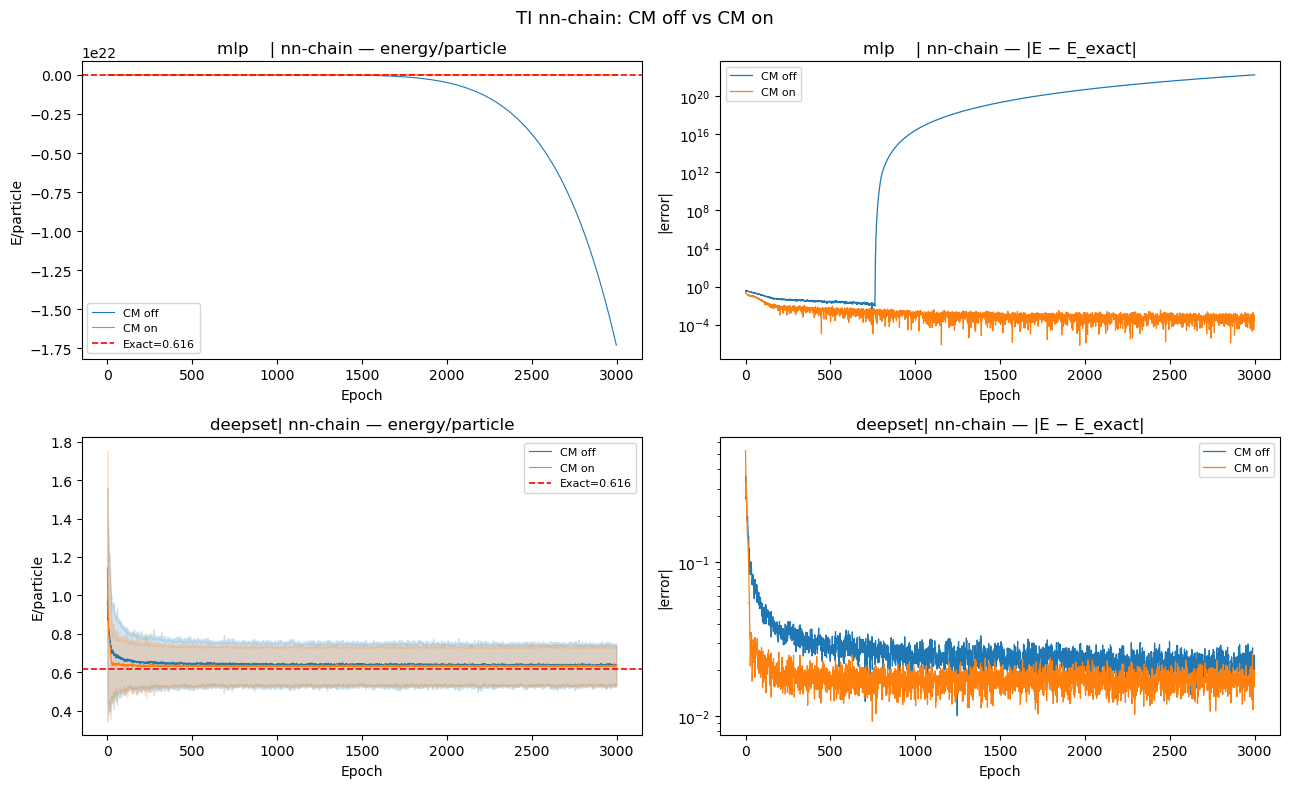

In [ ]:
def extract(history, E_exact_total):
    E  = np.array([s.energy for s in history]) / N_PARTICLES
    S  = np.array([s.std    for s in history]) / N_PARTICLES
    return E, S

steps = np.arange(N_EPOCHS)
COLORS = {False: "C0", True: "C1"}
LABELS = {False: "CM off", True: "CM on"}

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle("TI nn-chain: CM off vs CM on", fontsize=13)

for row, (label, _) in enumerate(NN_COMBOS):
    e_pp = E_exact_nn / N_PARTICLES

    # Energy trace
    ax = axes[row, 0]
    for use_cm in [False, True]:
        key = f"{label} CM={'on ' if use_cm else 'off'}"
        E, S = extract(results[key]["history"], E_exact_nn)
        c = COLORS[use_cm]; lbl = LABELS[use_cm]
        ax.plot(steps, E, lw=0.8, color=c, label=lbl)
        ax.fill_between(steps, E-S, E+S, alpha=0.2, color=c)
    ax.axhline(e_pp, color="red", ls="--", lw=1.2, label=f"Exact={e_pp:.3f}")
    ax.set_title(f"{label.strip()} — energy/particle")
    ax.set_xlabel("Epoch"); ax.set_ylabel("E/particle")
    ax.legend(fontsize=8)

    # |Error| log scale
    ax = axes[row, 1]
    for use_cm in [False, True]:
        key = f"{label} CM={'on ' if use_cm else 'off'}"
        E, _ = extract(results[key]["history"], E_exact_nn)
        c = COLORS[use_cm]; lbl = LABELS[use_cm]
        ax.semilogy(steps, np.abs(E - e_pp), lw=0.9, color=c, label=lbl)
    ax.set_title(f"{label.strip()} — |E − E_exact|")
    ax.set_xlabel("Epoch"); ax.set_ylabel("|error|")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("cm_nn_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

## Reference — Harmonic oscillator (CM off only)

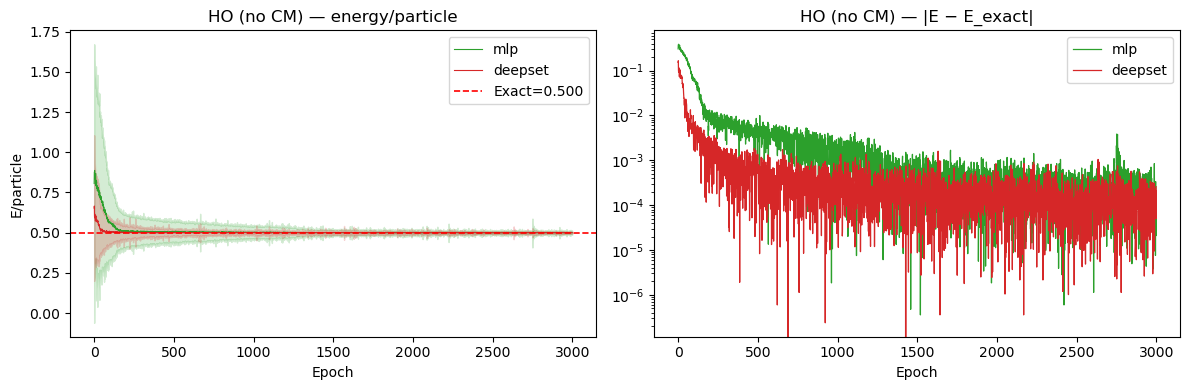

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
e_pp_ho = E_exact_ho / N_PARTICLES

for ax_idx, (label, _) in enumerate(HO_COMBOS):
    pass  # will plot both on same axes

ax_e, ax_err = axes
for color, (label, _) in zip(["C2", "C3"], HO_COMBOS):
    key = f"{label} CM=off"
    E, S = extract(results[key]["history"], E_exact_ho)
    lbl = label.strip().split("|")[0].strip()
    ax_e.plot(steps, E, lw=0.8, color=color, label=lbl)
    ax_e.fill_between(steps, E-S, E+S, alpha=0.2, color=color)
    ax_err.semilogy(steps, np.abs(E - e_pp_ho), lw=0.9, color=color, label=lbl)

ax_e.axhline(e_pp_ho, color="red", ls="--", lw=1.2, label=f"Exact={e_pp_ho:.3f}")
ax_e.set_title("HO (no CM) — energy/particle")
ax_e.set_xlabel("Epoch"); ax_e.set_ylabel("E/particle"); ax_e.legend()

ax_err.set_title("HO (no CM) — |E − E_exact|")
ax_err.set_xlabel("Epoch"); ax_err.legend()

plt.tight_layout()
plt.savefig("ho_reference.png", dpi=120, bbox_inches="tight")
plt.show()

## Summary table

In [ ]:
TAIL = 200
header = f"{'Run':<40} {'E_final/part':>12} {'σ/part':>8} {'E_exact/part':>13} {'|error|':>10}"
print(header)
print("-" * len(header))

for key, data in results.items():
    E, S = extract(data["history"], data["E_exact"])
    e_pp = data["E_exact"] / N_PARTICLES
    E_f, S_f = E[-TAIL:].mean(), S[-TAIL:].mean()
    print(f"{key:<40} {E_f:>12.5f} {S_f:>8.5f} {e_pp:>13.5f} {abs(E_f-e_pp):>10.5f}")

Run                                      E_final/part   σ/part  E_exact/part    |error|
---------------------------------------------------------------------------------------
mlp    | nn-chain CM=off                 -13268186592485318852608.00000      inf       0.61554 13268186592485318852608.00000
mlp    | nn-chain CM=on                       0.61599  0.02566       0.61554    0.00045
deepset| nn-chain CM=off                      0.63782  0.10864       0.61554    0.02228
deepset| nn-chain CM=on                       0.63266  0.10122       0.61554    0.01713
mlp    | HO CM=off                            0.50013  0.01263       0.50000    0.00013
deepset| HO CM=off                            0.50006  0.00669       0.50000    0.00006
